In [1]:
!pip install xarray
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install cartopy
!pip install geopandas
!pip install netCDF4
import cartopy.crs as ccrs
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.4 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving air2mtemp2000_2021_India.nc to air2mtemp2000_2021_India.nc


In [3]:
with xr.open_dataset("air2mtemp2000_2021_India.nc") as dta:
    lat = dta['lat'].values.astype(np.float32)
    lon = dta['lon'].values.astype(np.float32)
    ttl = dta['time'].values
    var = dta['air']

In [4]:
time=pd.DataFrame(ttl,columns=["Time"])
lat0 = 28.
lat1 = 32.
lon0 = 77.
lon1 = 81.


In [5]:
box=np.array([lat0, lat1, lon0, lon1], dtype=np.float64)
idx_lat = np.where((lat >= box[0]) & (lat <= box[1]))[0].astype(np.int32)
idx_lon = np.where((lon >= box[2]) & (lon <= box[3]))[0].astype(np.int32)
print(idx_lat.shape[0], idx_lon.shape[0])


2 2


In [6]:
r = var[:,:, idx_lat, idx_lon].values
crop_data = xr.Dataset(
    {
        'air': (('time','level','lat', 'lon'), r[:,:, :, :]),
    },
      coords={
        'time': ttl,
        'lat': lat[idx_lat],
        'lon': lon[idx_lon]
    })


In [7]:
crop_data.to_netcdf('/content/cropped_new1.nc')
file = '/content/cropped_new1.nc'

fh = Dataset(file, mode='r')
ds1=Dataset(file)
ds=xr.open_dataset('/content/cropped_new1.nc')
print(ds,ds1)


<xarray.Dataset> Size: 193kB
Dimensions:  (time: 8036, level: 1, lat: 2, lon: 2)
Coordinates:
  * time     (time) datetime64[ns] 64kB 2000-01-01 2000-01-02 ... 2021-12-31
  * lat      (lat) float32 8B 31.43 29.52
  * lon      (lon) float32 8B 78.75 80.62
Dimensions without coordinates: level
Data variables:
    air      (time, level, lat, lon) float32 129kB ... <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): time(8036), level(1), lat(2), lon(2)
    variables(dimensions): float32 air(time, level, lat, lon), int64 time(time), float32 lat(lat), float32 lon(lon)
    groups: 


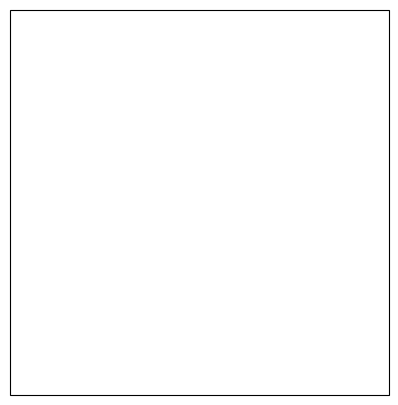

In [8]:
lat=ds["lat"].values
lon=ds["lon"].values
level=ds["level"].values
var=ds["air"][:,0,:,:].values

mean_var=var.mean(axis=0)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},figsize=(6,5))
ticksize=14
fontsize=16
ax.set_extent([min(lon),max(lon),min(lat),max(lat)],crs=ccrs.PlateCarree())

c=mean_var


In [9]:
mm = ax.contourf(lon,                   lat,                   c,                   transform=ccrs.PlateCarree(),                   cmap="RdBu_r",levels=50,extend='both')
ax.coastlines(resolution='110m');
ax.add_feature(cfeature.OCEAN.with_scale('110m'),zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale('50m'))
ax.add_feature(cfeature.STATES)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': ticksize, 'color': 'k','family':'serif'}
gl.ylabel_style = {'size': ticksize, 'color': 'k','family':'serif'}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
im_ratio = c.shape[0]/c.shape[1]
cb = plt.colorbar(mm, shrink=0.9, drawedges='True',pad=0.03,fraction=0.04*im_ratio)
cb.ax.tick_params(size=10,labelsize=ticksize)
cb.set_label(label='air 2m (K)',size=fontsize-2)



/tmp/ipykernel_5592/979907758.py:15: UserWarning: Adding colorbar to a different Figure <Figure size 600x500 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(mm, shrink=0.9, drawedges='True',pad=0.03,fraction=0.04*im_ratio)


<Figure size 640x480 with 0 Axes>

In [10]:
TimeSeries= var.reshape((var.shape[0], var.shape[1]*var.shape[2]))
df=pd.DataFrame(TimeSeries,index=time["Time"])

file=df.to_csv('/content/cropped_new1.nc',sep='\t',index=False)
coordinates=np.zeros((max(len(lat),len(lon)),2))
coordinates[:]=np.nan
coordinates[:len(lat),0]=lat
coordinates[:len(lon),1]=lon
df_coordinate=pd.DataFrame(coordinates,columns=['lat','lon'])
df_coordinate.to_csv('/content/cropped_new1.nc',index=False)

In [11]:
Nodes=[]
for i in range((lat.shape[0])):
    for j in range((lon.shape[0])):

        node=[lat[i],lon[j]]
        Nodes.append(node)
Nodes=np.array(Nodes)
Nodes=pd.DataFrame({'Latitude':Nodes[:, 0], 'Longitude': Nodes[:, 1]})
print(Nodes)

    Latitude  Longitude
0  31.428101     78.750
1  31.428101     80.625
2  29.523399     78.750
3  29.523399     80.625


In [12]:
Nodes.to_csv('/content/cropped_new1.nc',index=False)
idx=np.where((Nodes.iloc[:,0]==31.428101 ) & (Nodes.iloc[:,1]==80.625))[0][0]
timeseries=df.iloc[:,idx]
type(timeseries)
timeseries=pd.Series(timeseries,name="temp")
type(timeseries)
timeseries=timeseries.to_frame()
print(timeseries)

                  temp
Time                  
2000-01-01  258.820007
2000-01-02  256.830017
2000-01-03  256.599976
2000-01-04  259.700012
2000-01-05  259.020020
...                ...
2021-12-27  253.029999
2021-12-28  254.962494
2021-12-29  257.924988
2021-12-30  256.070007
2021-12-31  259.255005

[8036 rows x 1 columns]


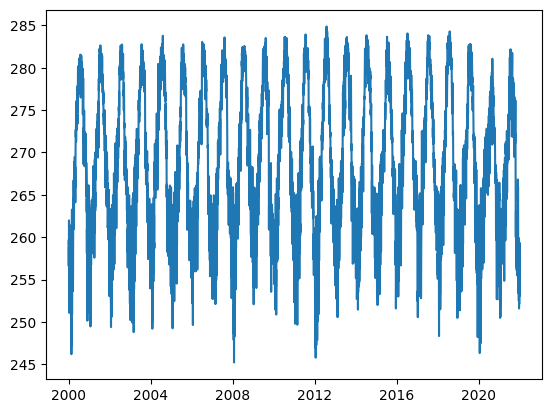

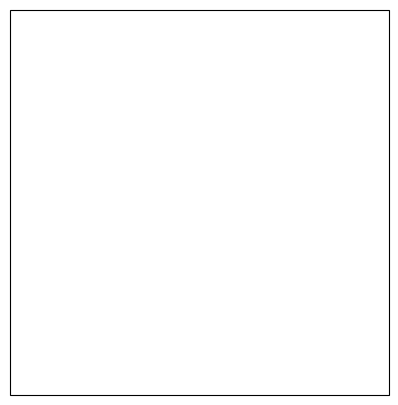

In [13]:
type(timeseries)
plt.plot(timeseries)
plt.show()

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(8,5))

ticksize=14
fontsize=16
ax.set_extent([min(lon),max(lon),min(lat),max(lat)],crs=ccrs.PlateCarree())

In [14]:
c=mean_var
mm = ax.contourf(lon,                   lat,                   c,                   transform=ccrs.PlateCarree(),                   cmap="Reds",levels=10,extend='both')
ax.scatter(80.625,31.428101,color="k",s=100,transform=ccrs.PlateCarree(),label="Study point")
ax.coastlines(resolution='110m');
ax.add_feature(cfeature.OCEAN.with_scale('110m'),zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale('50m'))
ax.add_feature(cfeature.STATES)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': ticksize, 'color': 'k','family':'serif'}
gl.ylabel_style = {'size': ticksize, 'color': 'k','family':'serif'}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
im_ratio = c.shape[0]/c.shape[1]
cb = fig.colorbar(mm, shrink=0.7,pad=0.05,ax=ax,orientation="vertical")
cb.ax.tick_params(size=10,labelsize=ticksize)
cb.set_label(label='air 2m (K)',size=fontsize-2)
ax.legend()


/tmp/ipykernel_5592/737892836.py:3: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(timeseries.index,timeseries,"-",color="k")


<Axes: xlabel='Time'>

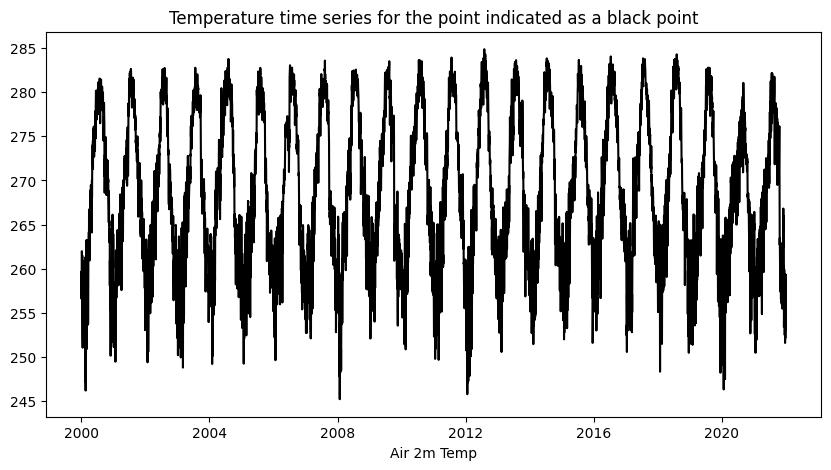

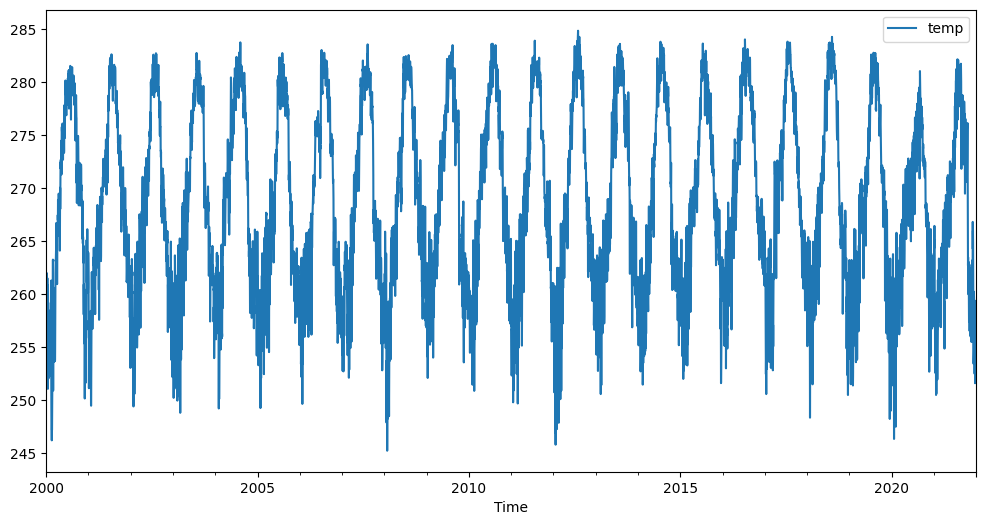

In [15]:
plt.figure(figsize=(10,5))

plt.plot_date(timeseries.index,timeseries,"-",color="k")

plt.xlabel("Time")
plt.xlabel("Air 2m Temp")

plt.title("Temperature time series for the point indicated as a black point")

len(timeseries)
timeseries.plot(figsize=[12,6])



In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam



In [17]:
dataset = timeseries.values
dataset = dataset.astype('float32')

In [19]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

In [20]:
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)


In [21]:
X = X.reshape(X.shape[0], X.shape[1], 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [22]:
model = Sequential()

model.add(GRU(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))

model.add(GRU(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,551 (95.90 KB)

 Trainable params: 24,551 (95.90 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0164 - val_loss: 0.0043
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0059 - val_loss: 0.0042
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0044 - val_loss: 0.0046
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 9/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0032 - val_loss: 0.0035
Epoch 10/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0031 - val_loss: 0.0036
Epoch 11/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0031 - val_loss: 0.0038
Epoch 12/20
201/201 ━━━━━━━━━━━━━━━━━

In [26]:
test_predict = model.predict(X_test)
train_predict = model.predict(X_train)

# Inverse transform
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


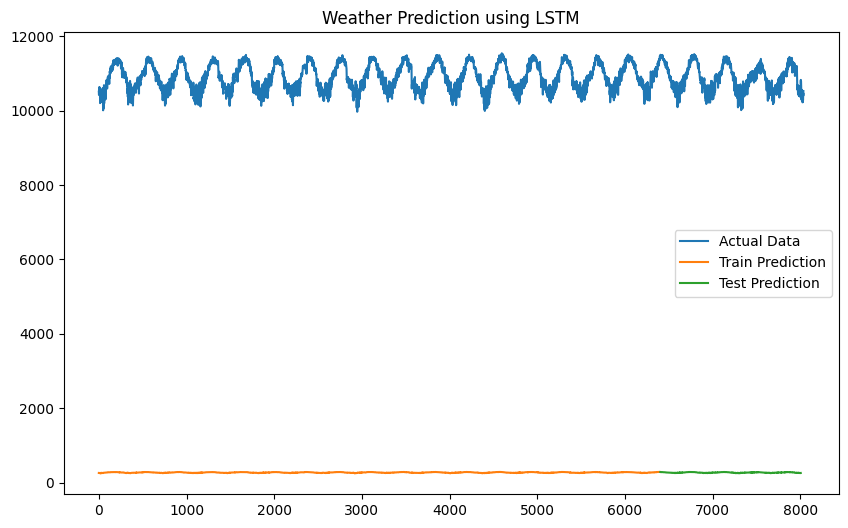

In [27]:
plt.figure(figsize=(10,6))
plt.plot(scaler.inverse_transform(dataset), label='Actual Data')
plt.plot(range(len(train_predict)), train_predict, label='Train Prediction')
plt.plot(range(len(train_predict), len(train_predict)+len(test_predict)), test_predict, label='Test Prediction')

plt.legend()
plt.title("Weather Prediction using LSTM")
plt.show()



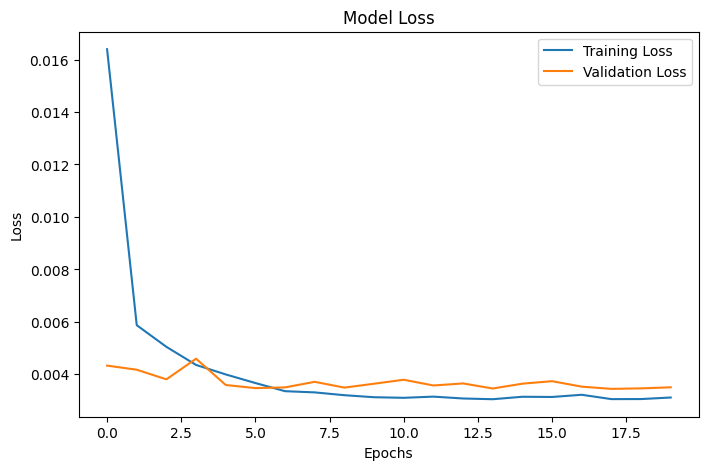

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

In [32]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(
    scaler.inverse_transform(y_test.reshape(-1,1)),
    test_predict
))

print("RMSE:", rmse)
rmse_percent = (rmse / (dataset.max() - dataset.min())) * 100
print("RMSE %:", rmse_percent)

import numpy as np

# Calculate error at each point
errors = scaler.inverse_transform(y_test.reshape(-1,1)) - test_predict

# RMSE at each point (absolute error)
rmse_series = np.sqrt(errors**2)



RMSE: 2.3480891433183455
RMSE %: 5.922042


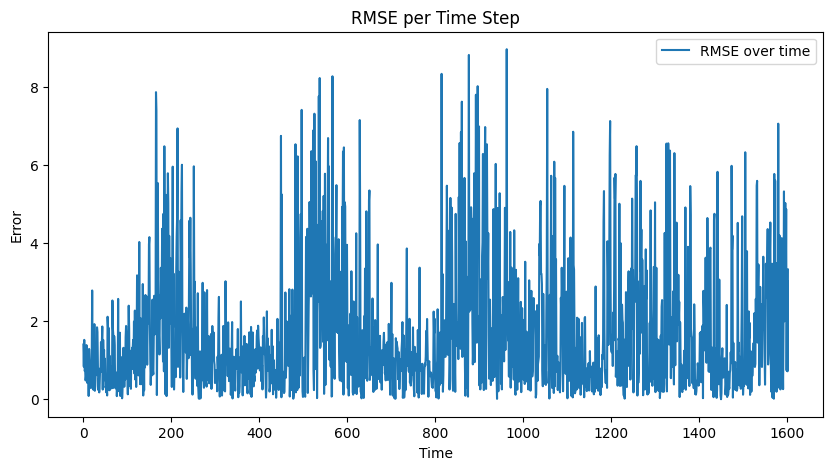

In [33]:
plt.figure(figsize=(10,5))
plt.plot(rmse_series, label="RMSE over time")
plt.title("RMSE per Time Step")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()